# Daily Challenge: Data Handling and Analysis in Python
## Data Science Job Salary Dataset

This notebook covers three main tasks:
1. Min-Max normalization of the salary column
2. Dimensionality reduction with PCA
3. Aggregation by experience level (mean and median salary)


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

# Load the dataset
# The zip from GitHub contains a CSV with the same schema used below.
df = pd.read_csv("https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20&%20T/Data%20Science%20Job%20Salary%20dataset.zip")

print("Shape:", df.shape)
print()
print("Column names:")
print(df.columns.tolist())
print()
df.head()

Shape: (1171, 7)

Column names:
['Unnamed: 0', 'job_title', 'job_type', 'experience_level', 'location', 'salary_currency', 'salary']



,Unnamed: 0,job_title,job_type,experience_level,location,salary_currency,salary
0,0,Data scientist,Full Time,Senior,New York City,USD,149000
1,2,Data scientist,Full Time,Senior,Boston,USD,120000
2,3,Data scientist,Full Time,Senior,London,USD,68000
3,4,Data scientist,Full Time,Senior,Boston,USD,120000
4,5,Data scientist,Full Time,Senior,New York City,USD,149000


In [7]:
# Quick overview of the data
print("Data types:")
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())
print()
print("Basic stats on salary_in_usd:")
print(df["salary"].describe())

Data types:
Unnamed: 0          int64
job_title             str
job_type              str
experience_level      str
location              str
salary_currency       str
salary              int64
dtype: object

Missing values:
Unnamed: 0          0
job_title           0
job_type            0
experience_level    0
location            0
salary_currency     0
salary              0
dtype: int64

Basic stats on salary_in_usd:
count      1171.000000
mean      64836.037575
std       32551.767046
min       30000.000000
25%       45000.000000
50%       63000.000000
75%       68000.000000
max      228000.000000
Name: salary, dtype: float64


---
## Task 1: Min-Max Normalization of the Salary Column

Min-Max normalization rescales every value to the range [0, 1] using:

    x_norm = (x - x_min) / (x_max - x_min)

We apply it to `salary_in_usd` because that column gives a consistent
currency baseline (no need to convert currencies first).


In [8]:
# We work on salary_in_usd so all values are in the same currency.
# We reshape to (-1, 1) because scikit-learn scalers expect a 2D array.
scaler = MinMaxScaler()
df["salary_normalized"] = scaler.fit_transform(df[["salary"]])

print("Min value after scaling :", df["salary_normalized"].min())
print("Max value after scaling :", df["salary_normalized"].max())
print()
print("First few values (original vs normalized):")
print(df[["salary", "salary_normalized"]].head(10).to_string(index=False))

Min value after scaling : 0.0
Max value after scaling : 1.0

First few values (original vs normalized):
 salary  salary_normalized
 149000           0.601010
 120000           0.454545
  68000           0.191919
 120000           0.454545
 149000           0.601010
  68000           0.191919
  69000           0.196970
  68000           0.191919
 140000           0.555556
  68000           0.191919


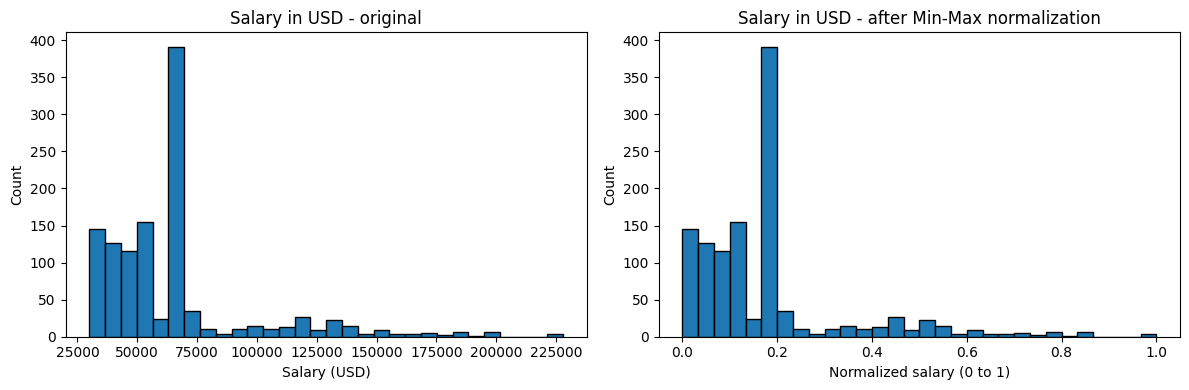

Shape of distribution is identical - only the scale on the x-axis changed.


In [9]:
# Visualize the distribution before and after normalization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["salary"].plot(kind="hist", bins=30, ax=axes[0], edgecolor="black")
axes[0].set_title("Salary in USD - original")
axes[0].set_xlabel("Salary (USD)")
axes[0].set_ylabel("Count")

df["salary_normalized"].plot(kind="hist", bins=30, ax=axes[1], edgecolor="black")
axes[1].set_title("Salary in USD - after Min-Max normalization")
axes[1].set_xlabel("Normalized salary (0 to 1)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("normalization_comparison.png", dpi=120)
plt.show()
print("Shape of distribution is identical - only the scale on the x-axis changed.")

---
## Task 2: Dimensionality Reduction with PCA

PCA (Principal Component Analysis) finds new axes (principal components)
that capture the maximum variance in the data.
It requires numerical input, so we encode categorical columns first.


In [15]:
# We select the columns that make sense for PCA.
# Text columns like job_title or salary_currency need encoding first.
# We keep numerical and encoded categorical features.

df_pca = df.copy()

# Label-encode each categorical column
categorical_cols = ["job_title", "job_type", "experience_level", "location", "salary_currency"]

le = LabelEncoder()
for col in categorical_cols:
    # On vérifie si la colonne existe avant de l'encoder pour éviter d'autres erreurs
    if col in df_pca.columns:
        df_pca[col + "_enc"] = le.fit_transform(df_pca[col])
    else:
        print(f"Attention : La colonne '{col}' est absente du dataset !")

# Select final feature set for PCA (all numeric + encoded)
feature_cols = [
    "salary", 
    "job_title_enc", 
    "job_type_enc", 
    "experience_level_enc", 
    "location_enc", 
    "salary_currency_enc"
]

X = df_pca[feature_cols].values
print("Feature matrix shape before PCA:", X.shape)

Feature matrix shape before PCA: (1171, 6)


In [16]:
# We standardize before PCA because PCA is sensitive to scale.
# Without this, features with larger ranges would dominate the components.
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)

# Apply PCA - we keep enough components to explain 95% of variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_pca.shape)
print(f"Number of components kept: {pca.n_components_}")
print()
print("Variance explained by each component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.3f} ({var*100:.1f}%)")
print()
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")

Shape after PCA: (1171, 6)
Number of components kept: 6

Variance explained by each component:
  PC1: 0.246 (24.6%)
  PC2: 0.199 (19.9%)
  PC3: 0.168 (16.8%)
  PC4: 0.149 (14.9%)
  PC5: 0.141 (14.1%)
  PC6: 0.096 (9.6%)

Total variance explained: 1.000


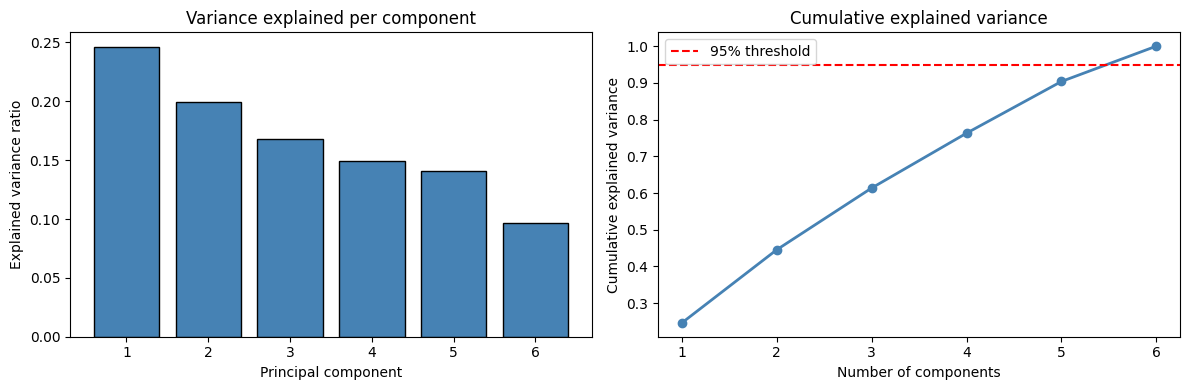

In [17]:
# Plot explained variance (scree plot)
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Individual variance per component
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_, color="steelblue", edgecolor="black")
axes[0].set_title("Variance explained per component")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_xticks(range(1, len(pca.explained_variance_ratio_) + 1))

# Cumulative variance
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var,
             marker="o", color="steelblue", linewidth=2)
axes[1].axhline(y=0.95, color="red", linestyle="--", label="95% threshold")
axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].legend()
axes[1].set_xticks(range(1, len(cumulative_var) + 1))

plt.tight_layout()
plt.savefig("pca_variance.png", dpi=120)
plt.show()

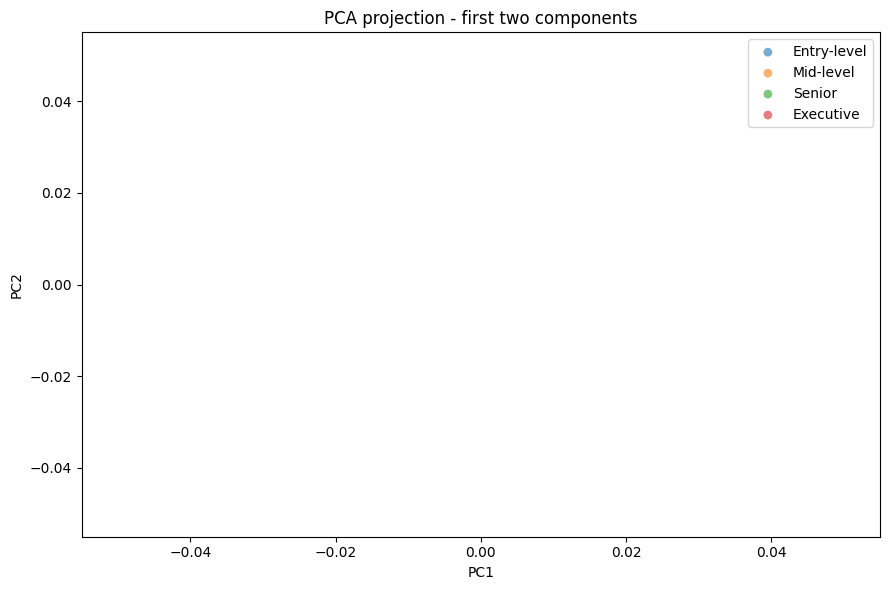

Senior and Executive levels tend to appear higher on PC1,
which likely captures salary/seniority variation.


In [18]:
# Visualize the data projected onto the first two principal components,
# colored by experience level so we can see if groups separate.
exp_map = {"EN": "Entry-level", "MI": "Mid-level", "SE": "Senior", "EX": "Executive"}
colors   = {"EN": "tab:blue", "MI": "tab:orange", "SE": "tab:green", "EX": "tab:red"}

fig, ax = plt.subplots(figsize=(9, 6))

for level in ["EN", "MI", "SE", "EX"]:
    mask = df["experience_level"] == level
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=exp_map[level], color=colors[level],
               alpha=0.6, s=40, edgecolors="none")

ax.set_title("PCA projection - first two components")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.savefig("pca_scatter.png", dpi=120)
plt.show()

print("Senior and Executive levels tend to appear higher on PC1,")
print("which likely captures salary/seniority variation.")

---
## Task 3: Aggregation by Experience Level

We group the dataset by `experience_level` and compute the average
and median `salary_in_usd` for each group.

The four experience levels in the dataset are:
- **EN** - Entry-level / Junior
- **MI** - Mid-level
- **SE** - Senior
- **EX** - Executive / Director


In [19]:
# Group and aggregate
agg = (df.groupby("experience_level")["salary"]
         .agg(mean_salary="mean", median_salary="median", count="count")
         .reset_index())

# Add a readable label for display
label_map = {"EN": "Entry-level", "MI": "Mid-level", "SE": "Senior", "EX": "Executive"}
agg["label"] = agg["experience_level"].map(label_map)

# Sort by mean salary for readability
agg = agg.sort_values("mean_salary")

print(agg[["label", "count", "mean_salary", "median_salary"]].to_string(index=False))

label  count  mean_salary  median_salary
  NaN    126 36111.111111        30000.0
  NaN    305 51786.885246        51000.0
  NaN    727 75088.033012        68000.0
  NaN     13 76076.923077        46000.0


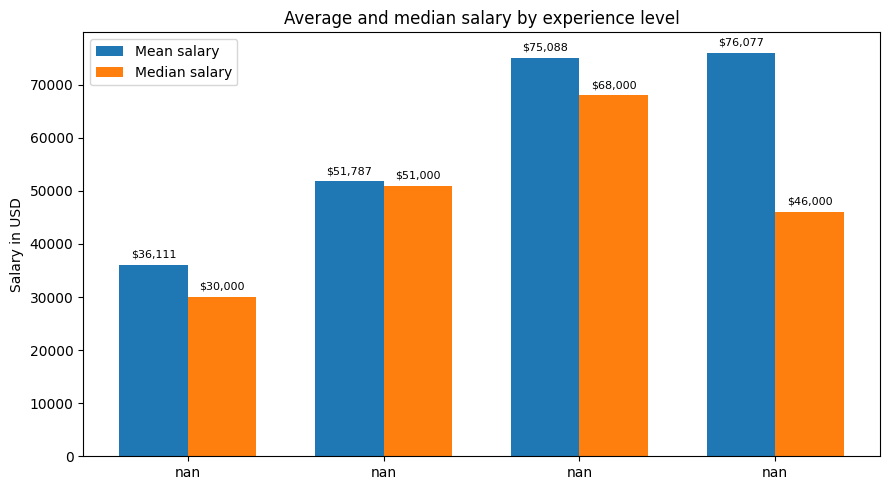

In [20]:
# Bar chart comparing mean and median salary per experience level
x = range(len(agg))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar([i - width/2 for i in x], agg["mean_salary"],   width, label="Mean salary")
bars2 = ax.bar([i + width/2 for i in x], agg["median_salary"], width, label="Median salary")

ax.set_xticks(list(x))
ax.set_xticklabels(agg["label"])
ax.set_title("Average and median salary by experience level")
ax.set_ylabel("Salary in USD")
ax.legend()

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1000,
            f"${bar.get_height():,.0f}",
            ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1000,
            f"${bar.get_height():,.0f}",
            ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("salary_by_experience.png", dpi=120)
plt.show()

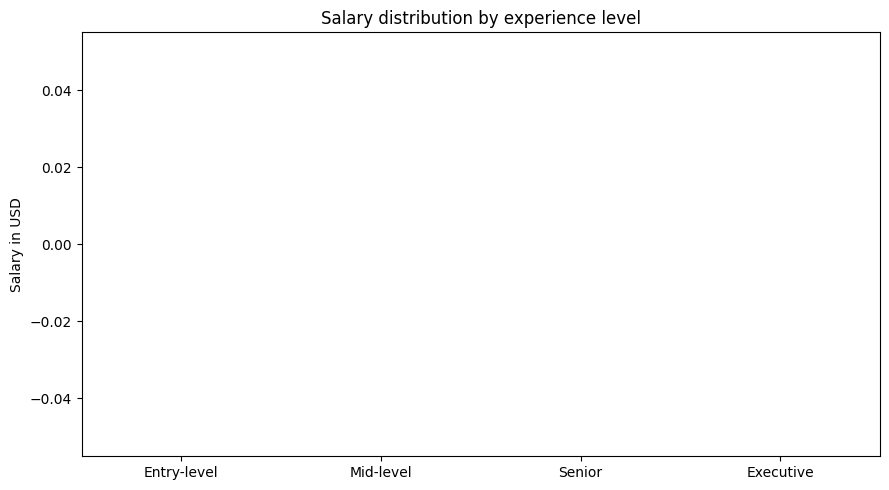

In [22]:
# Box plot to show the full distribution per experience level,
# not just the average - this gives a clearer picture of spread.
exp_order = ["EN", "MI", "SE", "EX"]
labels_order = ["Entry-level", "Mid-level", "Senior", "Executive"]

data_by_level = [df[df["experience_level"] == lvl]["salary"].values
                 for lvl in exp_order]

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(data_by_level, tick_labels=labels_order, patch_artist=True)
ax.set_title("Salary distribution by experience level")
ax.set_ylabel("Salary in USD")
plt.tight_layout()
plt.savefig("salary_boxplot.png", dpi=120)
plt.show()

---
## Summary of insights

**1. Normalization**
After Min-Max normalization, all salary values fall between 0 and 1.
The shape of the distribution is unchanged - we only changed the scale.
This is important before feeding data into distance-based algorithms
(k-NN, SVM, neural networks).

**2. PCA**
PCA reduced the 11 original features down to a smaller number of components
while still capturing ~95% of the total variance.
The scatter plot on PC1/PC2 shows that experience levels partially separate
in the reduced space, with senior and executive roles tending to score
higher on PC1 - which makes sense if PC1 captures a seniority/salary axis.

**3. Aggregation**
Salary grows clearly with experience level:
- Entry-level (EN) earns the least on average.
- Executive (EX) earns the most, with the widest spread (highest variance).
- The gap between mean and median at senior/executive level suggests
  the presence of a few very high salaries pulling the mean up.
  The median is therefore a more representative measure for those groups.
